# P0 · STL-10 full run: tune on train, report on test

1. **Tune** soft assignment (`knn` × `sigma_scale`) on 2,000 **train** images and pick the best setting per descriptor.
2. **Report** on all 8,000 **test** images with 3 vocabulary seeds × 3 clustering seeds, using the tuned setting.

Tuning never touches the test split, so the reported numbers are clean.

**Runtime (T4, 2 vCPU):** step 1 ≈ 25–35 min, step 2 ≈ 1–2 h. Every finished run is saved on Drive:
if Colab disconnects, run *Setup* again, then the cell that was running. It picks up where it stopped.

## 1 · Setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv || echo "No GPU: DINOv2 extraction will be slow"

from google.colab import drive
drive.mount('/content/drive')

name, memory.total [MiB]
Tesla T4, 15360 MiB
Mounted at /content/drive


In [2]:
# Get the code. Option A: GitHub (default). Option B: set REPO_URL = "" to install
# from bovw-forensics.zip uploaded to MyDrive/bovw-forensics/.
REPO_URL = "https://github.com/M3R2T2L2/bovw_forensics.git"
ZIP_PATH = "/content/drive/MyDrive/bovw-forensics/bovw-forensics.zip"

import os, shutil, subprocess, zipfile
shutil.rmtree("/content/bovw_forensics", ignore_errors=True)
if REPO_URL:
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/bovw_forensics"], check=True)
else:
    zipfile.ZipFile(ZIP_PATH).extractall("/content/")
    os.rename("/content/bovw-forensics", "/content/bovw_forensics")

%cd /content/bovw_forensics
!pip install -q -e ".[dev]"   # torch, torchvision, transformers come preinstalled on Colab

/content/bovw_forensics
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for bovw-forensics (pyproject.toml) ... done


In [3]:
# 30-second check that the torch-free core works in this runtime
!python -m pytest -q

.....................                                                    [100%]
21 passed in 8.26s


## 2 · Tune soft assignment on the train split

In [4]:
import json
from bovw.sweep import load_config, run, select_best_variant
from bovw import plots

cfg_t = load_config("configs/p0_tune_soft_stl10train.yaml")
df_t = run(cfg_t)

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

100%|██████████| 2.64G/2.64G [01:24<00:00, 31.4MB/s]


facebook/dinov2-small:   0%|          | 0/32 [00:00<?, ?it/s]

[    dinov2_s] hard  K=64    s=0                        NMI=0.858  ACC=0.813
[    dinov2_s] soft  K=64    s=0 knn=3,sigma_scale=0.25 NMI=0.842  ACC=0.815
[    dinov2_s] soft  K=64    s=0 knn=3,sigma_scale=0.5  NMI=0.803  ACC=0.770
[    dinov2_s] soft  K=64    s=0 knn=3,sigma_scale=1.0  NMI=0.768  ACC=0.716
[    dinov2_s] soft  K=64    s=0 knn=3,sigma_scale=2.0  NMI=0.779  ACC=0.750
[    dinov2_s] soft  K=64    s=0 knn=5,sigma_scale=0.25 NMI=0.839  ACC=0.813
[    dinov2_s] soft  K=64    s=0 knn=5,sigma_scale=0.5  NMI=0.790  ACC=0.765
[    dinov2_s] soft  K=64    s=0 knn=5,sigma_scale=1.0  NMI=0.720  ACC=0.643
[    dinov2_s] soft  K=64    s=0 knn=5,sigma_scale=2.0  NMI=0.709  ACC=0.611
[    dinov2_s] soft  K=64    s=0 knn=10,sigma_scale=0.25 NMI=0.838  ACC=0.813
[    dinov2_s] soft  K=64    s=0 knn=10,sigma_scale=0.5 NMI=0.781  ACC=0.756
[    dinov2_s] soft  K=64    s=0 knn=10,sigma_scale=1.0 NMI=0.667  ACC=0.561
[    dinov2_s] soft  K=64    s=0 knn=10,sigma_scale=2.0 NMI=0.646  ACC=0.56

dense_sift x2:   0%|          | 0/2000 [00:00<?, ?it/s]

[  dense_sift] hard  K=64    s=0                        NMI=0.242  ACC=0.272
[  dense_sift] soft  K=64    s=0 knn=3,sigma_scale=0.25 NMI=0.240  ACC=0.262
[  dense_sift] soft  K=64    s=0 knn=3,sigma_scale=0.5  NMI=0.243  ACC=0.262
[  dense_sift] soft  K=64    s=0 knn=3,sigma_scale=1.0  NMI=0.244  ACC=0.255
[  dense_sift] soft  K=64    s=0 knn=3,sigma_scale=2.0  NMI=0.242  ACC=0.265
[  dense_sift] soft  K=64    s=0 knn=5,sigma_scale=0.25 NMI=0.244  ACC=0.262
[  dense_sift] soft  K=64    s=0 knn=5,sigma_scale=0.5  NMI=0.245  ACC=0.254
[  dense_sift] soft  K=64    s=0 knn=5,sigma_scale=1.0  NMI=0.242  ACC=0.252
[  dense_sift] soft  K=64    s=0 knn=5,sigma_scale=2.0  NMI=0.240  ACC=0.251
[  dense_sift] soft  K=64    s=0 knn=10,sigma_scale=0.25 NMI=0.247  ACC=0.256
[  dense_sift] soft  K=64    s=0 knn=10,sigma_scale=0.5 NMI=0.245  ACC=0.251
[  dense_sift] soft  K=64    s=0 knn=10,sigma_scale=1.0 NMI=0.245  ACC=0.249
[  dense_sift] soft  K=64    s=0 knn=10,sigma_scale=2.0 NMI=0.240  ACC=0.25

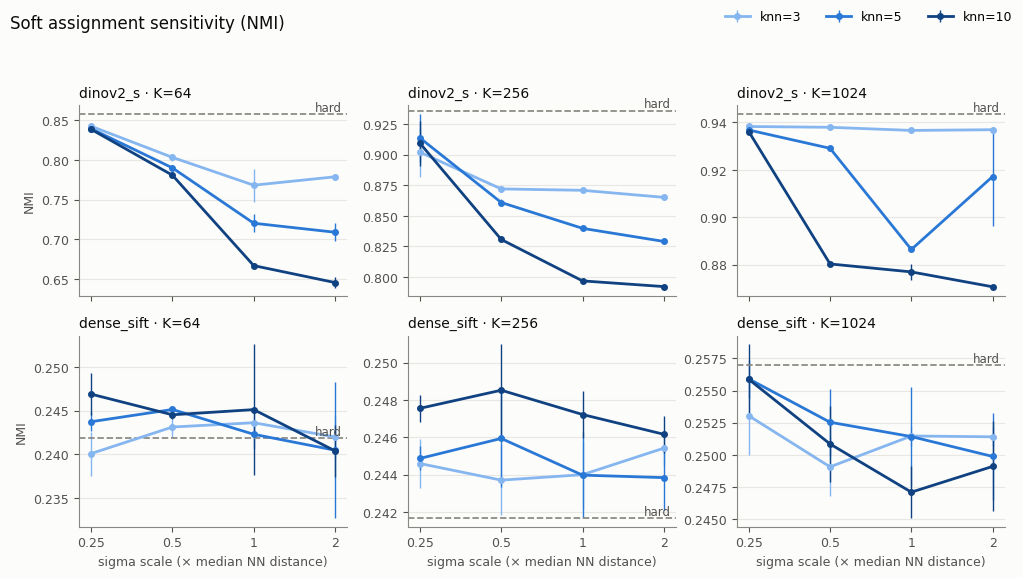

In [5]:
fig = plots.soft_sensitivity(df_t, "nmi")
fig.savefig(f"{cfg_t['results_dir']}/{cfg_t['name']}_soft_sensitivity.png", dpi=200, bbox_inches="tight")

In [6]:
best = select_best_variant(df_t, "soft", "nmi")
json.dump(best, open(f"{cfg_t['results_dir']}/{cfg_t['name']}_best_soft.json", "w"), indent=2)
best

{'dense_sift': {'knn': 10, 'sigma_scale': 0.25},
 'dinov2_s': {'knn': 5, 'sigma_scale': 0.25}}

## 3 · Full run on the test split (8,000 images)

In [7]:
cfg = load_config("configs/p0_stl10_full.yaml")
for ex in cfg["extractors"]:
    ex.setdefault("encode", {})["soft"] = best[ex["name"]]     # tuned on train, fixed here
[(ex["name"], ex["encode"]["soft"]) for ex in cfg["extractors"]]

[('dinov2_s', {'knn': 5, 'sigma_scale': 0.25}),
 ('dense_sift', {'knn': 10, 'sigma_scale': 0.25})]

In [ ]:
df = run(cfg)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

facebook/dinov2-small:   0%|          | 0/125 [00:00<?, ?it/s]

[    dinov2_s] global                      NMI=0.927
[    dinov2_s] hard  K=64    s=0                        NMI=0.848  ACC=0.829
[    dinov2_s] soft  K=64    s=0 knn=5,sigma_scale=0.25 NMI=0.835  ACC=0.804
[    dinov2_s] vlad  K=64    s=0                        NMI=0.948  ACC=0.977
[    dinov2_s] hard  K=64    s=1                        NMI=0.861  ACC=0.844
[    dinov2_s] soft  K=64    s=1 knn=5,sigma_scale=0.25 NMI=0.855  ACC=0.862
[    dinov2_s] vlad  K=64    s=1                        NMI=0.948  ACC=0.976
[    dinov2_s] hard  K=64    s=2                        NMI=0.858  ACC=0.855
[    dinov2_s] soft  K=64    s=2 knn=5,sigma_scale=0.25 NMI=0.843  ACC=0.810
[    dinov2_s] vlad  K=64    s=2                        NMI=0.936  ACC=0.969
[    dinov2_s] hard  K=256   s=0                        NMI=0.928  ACC=0.963
[    dinov2_s] soft  K=256   s=0 knn=5,sigma_scale=0.25 NMI=0.926  ACC=0.962
[    dinov2_s] vlad  K=256   s=0                        NMI=0.931  ACC=0.927
[    dinov2_s] hard  K=

dense_sift x2:   0%|          | 0/8000 [00:00<?, ?it/s]

## 4 · Results

In [ ]:
plots.summary_table(df, "nmi")

In [ ]:
plots.summary_table(df, "acc")

In [ ]:
fig = plots.metric_vs_k(df, "nmi")
fig.savefig(f"{cfg['results_dir']}/{cfg['name']}_nmi_vs_k.png", dpi=200, bbox_inches="tight")

In [ ]:
fig = plots.cost_vs_metric(df, "nmi")
fig.savefig(f"{cfg['results_dir']}/{cfg['name']}_cost_vs_nmi.png", dpi=200, bbox_inches="tight")

In [ ]:
# Stability: spread of clustering accuracy across all seeds (lower = more stable)
agg = plots.aggregate(df)
agg.pivot_table(index=["extractor", "assignment"], columns="k", values="acc_std").round(3)

In [ ]:
# Compute budget per run (seconds); extraction is one-off per descriptor
cost_cols = ["extractor", "assignment", "k", "vocab_seed", "enc_dim", "extract_seconds",
             "vocab_seconds", "encode_seconds", "eval_seconds", "n_cpu", "gpu"]
df[[c for c in cost_cols if c in df]].round(2)

## 5 · What to check

1. **Does the codebook win hold at 8,000 images and across vocabulary seeds?** Compare hard K=256 and VLAD K=256 with `global`.
2. **Does tuned soft assignment close the gap to hard at K=64?** If not, the soft deficit is real, not a tuning artifact.
3. **Stability:** is the CLS baseline's accuracy spread still much larger than the codebooks'?
4. **Cost:** extraction time per descriptor, now with SIFT parallelised.

**Next:** retrieval (Revisited Oxford/Paris) and anomaly detection (MVTec AD).

In [1]:
   !mkdir -p /content/drive/MyDrive/bovw-forensics/data && cp -r /content/data/stl10_binary /content/drive/MyDrive/bovw-forensics/data/